análise de sentimentos nos dados #edtwt

In [1]:
%pip install transformers torch spacy pandas numpy matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import spacy

from transformers import pipeline
from IPython.display import display, HTML

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

In [3]:
!python -m spacy download pt_core_news_lg --quiet

nlp = spacy.load("pt_core_news_lg")
print('modelo spacy pt_core_news_lg carregado.')


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
Modelo spaCy pt_core_news_lg carregado.


carregamento dos dados

In [4]:
DATA_DIR = os.getcwd()
csv_path = os.path.join(DATA_DIR, "../entregas/p3/entrega_3.csv")

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Arquivo não encontrado: {csv_path}")

df = pd.read_csv(csv_path)
print(f"Total de tweets no corpus: {df.shape[0]}")

AMOSTRA = 50
df_amostra = df.sample(n=AMOSTRA, random_state=12).reset_index(drop=True)
tweets = df_amostra["text"].tolist()
print(f"Amostra selecionada: {len(tweets)} tweets")
df_amostra[["text"]].head(5)

Total de tweets no corpus: 2815
Amostra selecionada: 50 tweets


,text
0,@amolacraias pensei que eu tava scrollando o #...
1,Conheço tanto meu corpo que me nem percebi que...
2,De ontem ₍ᐢ. .ᐢ₎ #wieiad \nAmo comer limpinho!...
3,Fotito de mis compras de gorda trastornada🍓🌸 #...
4,@X0Azura @seilausuario @tayrilivia sendo que o...


análise de opiniões com spacy

In [5]:
texto_exemplo = tweets[0]
print(f"Texto analisado:\n{texto_exemplo}\n")

doc = nlp(texto_exemplo)

print('=== opiniões / polaridade ===\n')

adjetivos_encontrados = False
for token in doc:
    if token.pos_ == "ADJ":
        print(f"Adjetivo: {token.text} → relacionado a: {token.head.text} (função: {token.dep_})")
        adjetivos_encontrados = True

if not adjetivos_encontrados:
    print('nenhum adjetivo encontrado neste tweet.')

print()

for token in doc:
    if token.text.lower() in ["mas", "porém", "contudo", "todavia", "entretanto"]:
        print(f"Conector adversativo identificado: '{token.text}' (pode inverter ou moderar o sentimento)")


Texto analisado:
@amolacraias pensei que eu tava scrollando o #edtwt

=== OPINIÕES / POLARIDADE ===

Nenhum adjetivo encontrado neste tweet.



análise de sentimentos com transformers

In [6]:
sent_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)
print('pipeline de sentimentos carregado.')

Device set to use mps:0


Pipeline de sentimentos carregado.


resultados no corpus (amostra)

In [7]:
resultados = []
for texto in tweets:
    texto_truncado = texto[:800]
    resultado = sent_pipeline(texto_truncado)[0]
    estrelas = int(resultado["label"][0])
    resultados.append({
        "texto": texto,
        "label": resultado["label"],
        "score": resultado["score"],
        "estrelas": estrelas
    })

df_sentimentos = pd.DataFrame(resultados)
print(f"Análise concluída para {len(df_sentimentos)} tweets.")
df_sentimentos.head(10)

Análise concluída para 50 tweets.


,texto,label,score,estrelas
0,@amolacraias pensei que eu tava scrollando o #...,1 star,0.619171,1
1,Conheço tanto meu corpo que me nem percebi que...,5 stars,0.475636,5
2,De ontem ₍ᐢ. .ᐢ₎ #wieiad \nAmo comer limpinho!...,1 star,0.337205,1
3,Fotito de mis compras de gorda trastornada🍓🌸 #...,5 stars,0.274522,5
4,@X0Azura @seilausuario @tayrilivia sendo que o...,1 star,0.442377,1
5,૮꒰ ˶• ༝ •˶꒱ა ♡ #wieiad #edtwt\n\nHj foi só um ...,2 stars,0.285817,2
6,comi dois paes c queijo hj me sentindo #obese ...,1 star,0.405553,1
7,Ed sinceridade eu to gorda nessa foto? E quant...,1 star,0.383622,1
8,to muito gordo meu deus #edtwt,5 stars,0.406272,5
9,AVISO ⚠️: essa é uma thread dedica ao #edtwt e...,1 star,0.737098,1


distribuição de sentimentos

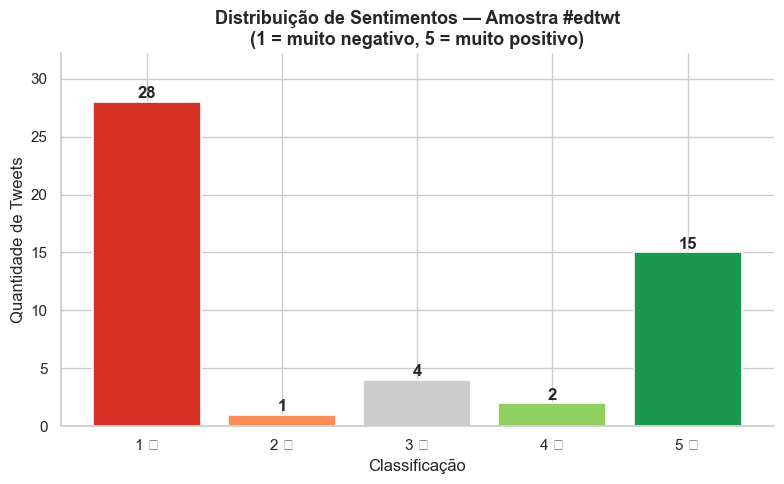


Média de estrelas: 2.50
Mediana de estrelas: 1
Moda de estrelas: 1


In [8]:
contagem = df_sentimentos["estrelas"].value_counts().sort_index()

cores_sentimento = ["#d73027", "#fc8d59", "#cccccc", "#91cf60", "#1a9850"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    contagem.index.astype(str) + " ★",
    contagem.values,
    color=[cores_sentimento[i - 1] for i in contagem.index],
    edgecolor="white",
    linewidth=1.2
)

for bar, total in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(total), ha="center", fontweight="bold")

ax.set_title("Distribuição de Sentimentos — Amostra #edtwt\n(1 = muito negativo, 5 = muito positivo)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Classificação")
ax.set_ylabel("Quantidade de Tweets")
ax.set_ylim(0, max(contagem.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nMédia de estrelas: {df_sentimentos['estrelas'].mean():.2f}")
print(f"Mediana de estrelas: {df_sentimentos['estrelas'].median():.0f}")
print(f"Moda de estrelas: {df_sentimentos['estrelas'].mode().values[0]}")


análise por sentença com visualização

In [9]:
texto_multisentenca = None
for texto in tweets:
    doc = nlp(texto[:800])
    sentencas = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 20]
    if len(sentencas) >= 2:
        texto_multisentenca = texto
        break

if texto_multisentenca is None:
    texto_multisentenca = tweets[0]
    doc = nlp(texto_multisentenca[:800])
    sentencas = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 0]
else:
    doc = nlp(texto_multisentenca[:800])
    sentencas = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 20]

print(f"Tweet selecionado:\n{texto_multisentenca}\n")
print(f"Sentenças extraídas: {len(sentencas)}\n")

resultados_sentencas = []
for sent in sentencas:
    resultado = sent_pipeline(sent)[0]
    resultados_sentencas.append((sent, resultado["label"], resultado["score"]))

for sent, label, score in resultados_sentencas:
    print(f"[{label} - Confiança: {score:.2f}] → {sent}")

Tweet selecionado:
Conheço tanto meu corpo que me nem percebi que tinha acabado a mestruação, perdi a noção do tempo, bebem mais 💦 Ajuda a melhorar o ciclo. #drepretwt #edtwt #drugtwt . https://t.co/GwfXuWbIUk

Sentenças extraídas: 3

[2 stars - Confiança: 0.23] → Conheço tanto meu corpo que me nem percebi que tinha acabado a mestruação, perdi a noção do tempo, bebem mais 💦
[4 stars - Confiança: 0.47] → Ajuda a melhorar o ciclo.
[1 star - Confiança: 0.23] → https://t.co/GwfXuWbIUk


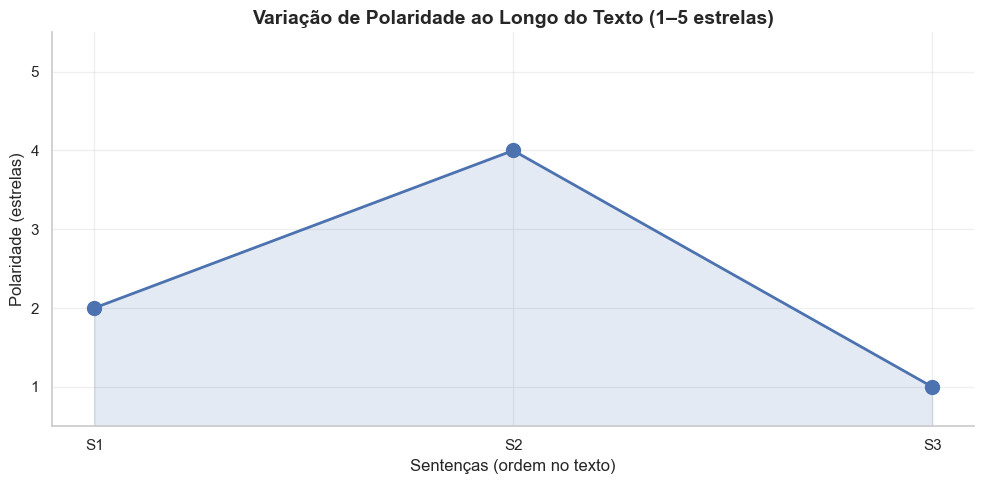

In [10]:
def label_para_numero(label):
    return int(label[0])  # label = "5 stars" → 5

valores_polaridade = [label_para_numero(label) for _, label, _ in resultados_sentencas]
sentencas_plot = [f"S{i+1}" for i in range(len(valores_polaridade))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sentencas_plot, valores_polaridade, marker='o', linestyle='-',
        linewidth=2, color="#4C72B0", markersize=10)
ax.fill_between(range(len(valores_polaridade)), valores_polaridade,
                alpha=0.15, color="#4C72B0")
ax.set_title("Variação de Polaridade ao Longo do Texto (1–5 estrelas)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Sentenças (ordem no texto)")
ax.set_ylabel("Polaridade (estrelas)")
ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [11]:
def cor_por_polaridade(estrelas):
    cores = {
        1: "#d73027",  # vermelho escuro
        2: "#fc8d59",  # laranja
        3: "#cccccc",  # cinza claro
        4: "#91cf60",  # verde claro
        5: "#1a9850",  # verde forte
    }
    return cores.get(estrelas, "#ffffff")

sentencas_html = []
for sent, label, score in resultados_sentencas:
    estrela = int(label[0])
    cor = cor_por_polaridade(estrela)
    html_sent = (
        f"<span style='background-color:{cor}; padding: 4px 8px;"
        f" border-radius: 6px; display:inline-block; margin:3px;"
        f" color:{'#fff' if estrela <= 2 or estrela >= 4 else '#333'};"
        f" font-size:14px'>{sent}</span>"
    )
    sentencas_html.append(html_sent)

display(HTML(
    "<h3>Sentenças coloridas por polaridade</h3>"
    "<p style='line-height:2.0em'>" + " ".join(sentencas_html) + "</p>"
    "<p style='color:#888; font-size:12px'>"
    "<span style='background-color:#d73027; color:#fff; padding:2px 6px; border-radius:3px'>Negativo</span> "
    "<span style='background-color:#cccccc; padding:2px 6px; border-radius:3px'>Neutro</span> "
    "<span style='background-color:#1a9850; color:#fff; padding:2px 6px; border-radius:3px'>Positivo</span>"
    "</p>"
))